<a href="https://colab.research.google.com/github/sofialindner/ntl-urban-expansion-mapping/blob/develop/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

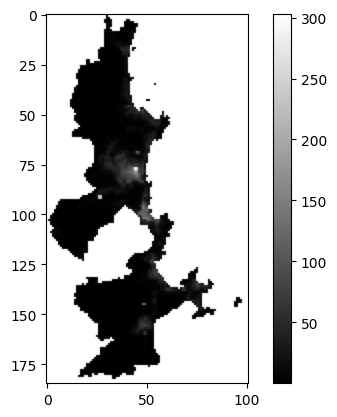

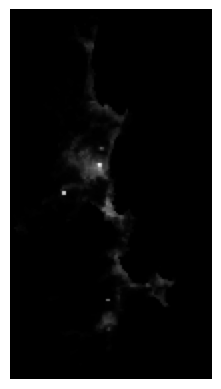

In [23]:
# Conversão de imagens .tif

import rasterio
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Abrir imagem .tif, preservando seus metadados
with rasterio.open('VIIRS_NTL_MedianaMensal_Blumenau_2019_01_reprojetada.tif') as src:
  img = src.read(1, masked=True) # Pixels mascarados pelo rasterio
  metadata = src.profile

# Exibir imagem com precisão float64
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.show()

# Preencher valores NaN mascarados
img_cv = img.filled(0)

# Preencher valores NaN reais
img_cv = np.nan_to_num(
    img_cv,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# Normalizar escala dos pixels para uso do OpenCV
img_cv = cv2.normalize(
    img_cv,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# Exibir imagem convertida OpenCV (uint8)
plt.imshow(img_cv, cmap='gray')
plt.axis('off')
plt.show()